# Chapter III: Exercise 1 - Part 1

## Reconstructing Earth’s Past – From a Snapshot to Deep Time

<figure>
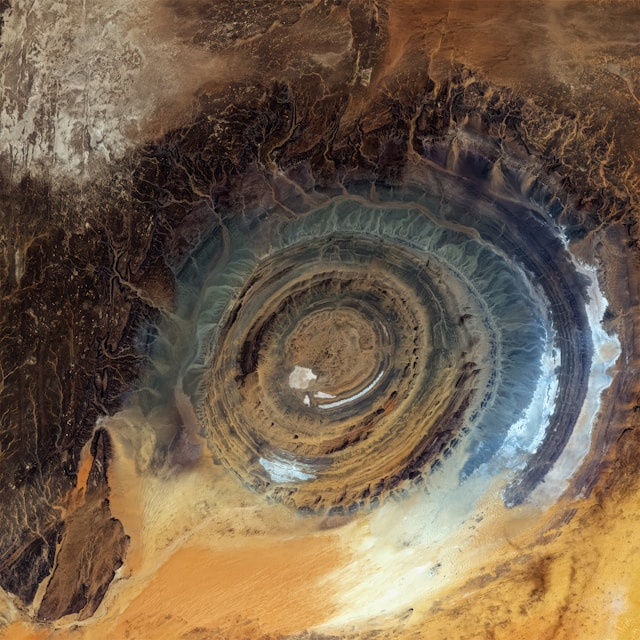
<figcaption aria-hidden="true">Richat Structure - Guelb er Richât
(Mauritania). Photo by USGS on Unsplash</figcaption>
</figure>



> **This exercise in brief**
>
> ### Big Question
>
> *How did Earth look 100 million years ago, and how has its geography
> changed over hundreds of millions of years?*
>
> ### What You Will Do
>
> In this module, you will:
>
> 1.  Start simple: Explore a single paleogeographic map and visualize
>     Earth at 100 Ma.
>
> 2.  Compare worlds: Compute and interpret differences in land and
>     ocean distribution between two time slices.
>
> 3.  Go deep time: Extend your analysis to the entire Phanerozoic (last
>     540 million years) and identify major trends.
>
> ### Why This Matters
>
> Earth’s geography controls climate, ocean circulation, and
> biodiversity. By reconstructing these changes, you’ll learn how
> scientists use data and coding to answer fundamental questions about
> our planet’s history.
>
> ### Your Tasks
>
> 1.  **Find the data:** Search on the web for maps of the Earth’s past.
>
> 2.  **Load and inspect:** Read raster data in Python, check metadata,
>     and understand its structure.
>
> 3.  **Compute basic stats:**
>
>     3.1. Land vs. ocean fraction for a chosen time slice.
>
>     3.2. Differences between two slices.
>
>     3.3. A time series of land fraction across the Phanerozoic.
>
> 4.  **Visualize:**
>
>     4.1 Global maps using matplotlib and cartopy.
>
>     4.2. A trend plot showing how land/ocean distribution evolved.
>
> ### Skills You Will Gain
>
> 1.  Working with GeoTIFFs in Python (rasterio, numpy).
> 2.  Performing basic geospatial analysis (masking, counting,
>     area-aware calculations).
> 3.  Creating global maps and time-series plots.
> 4.  Automating workflows for multi-step analysis.
>
> ### Points for Discussion
>
> - When we loaded the data and metadata from the GeoServer, we found a
>   `transform` attribute. What does this attribute describe ?
> - What are the pros and cons of using WCS requests, compared with
>   traditional ways, to access data ?
> - We got familiar with the masking function to discriminate land and
>   ocean. Could this mask be used to generate new statistics ? Which
>   ones ?
> - What is the use of these statistics in understanding the evolving
>   palaeogeography throughout the Phanerozoic ?

## Step-by-step instructions

### Install libraries

This tutorial requires the following libraries:

- `requests`
- `matplotlib`
- `rasterio`
- `numpy`

You can check if they are installed (and check which version you have)
by running:

In [1]:
libs = ["requests", "matplotlib", "rasterio", "numpy"]

for lib in libs:
    try:
        module = __import__(lib)
        print(lib + " is installed")
    except ImportError:
        print(lib + " is NOT installed")

If you encounter an error, come back to [Chapter II: Setting up your
Python
environment](https://unige-cgeom.github.io/SPACE-GEOLOGY/course/chapter2_setup.html)
and follow the instructions.

### Find the data

You want to learn what the Earth looked like 100 millions of years ago.
Where do you look for such kind of data ?

Using a search engine, results will typically yield something like:

<figure>
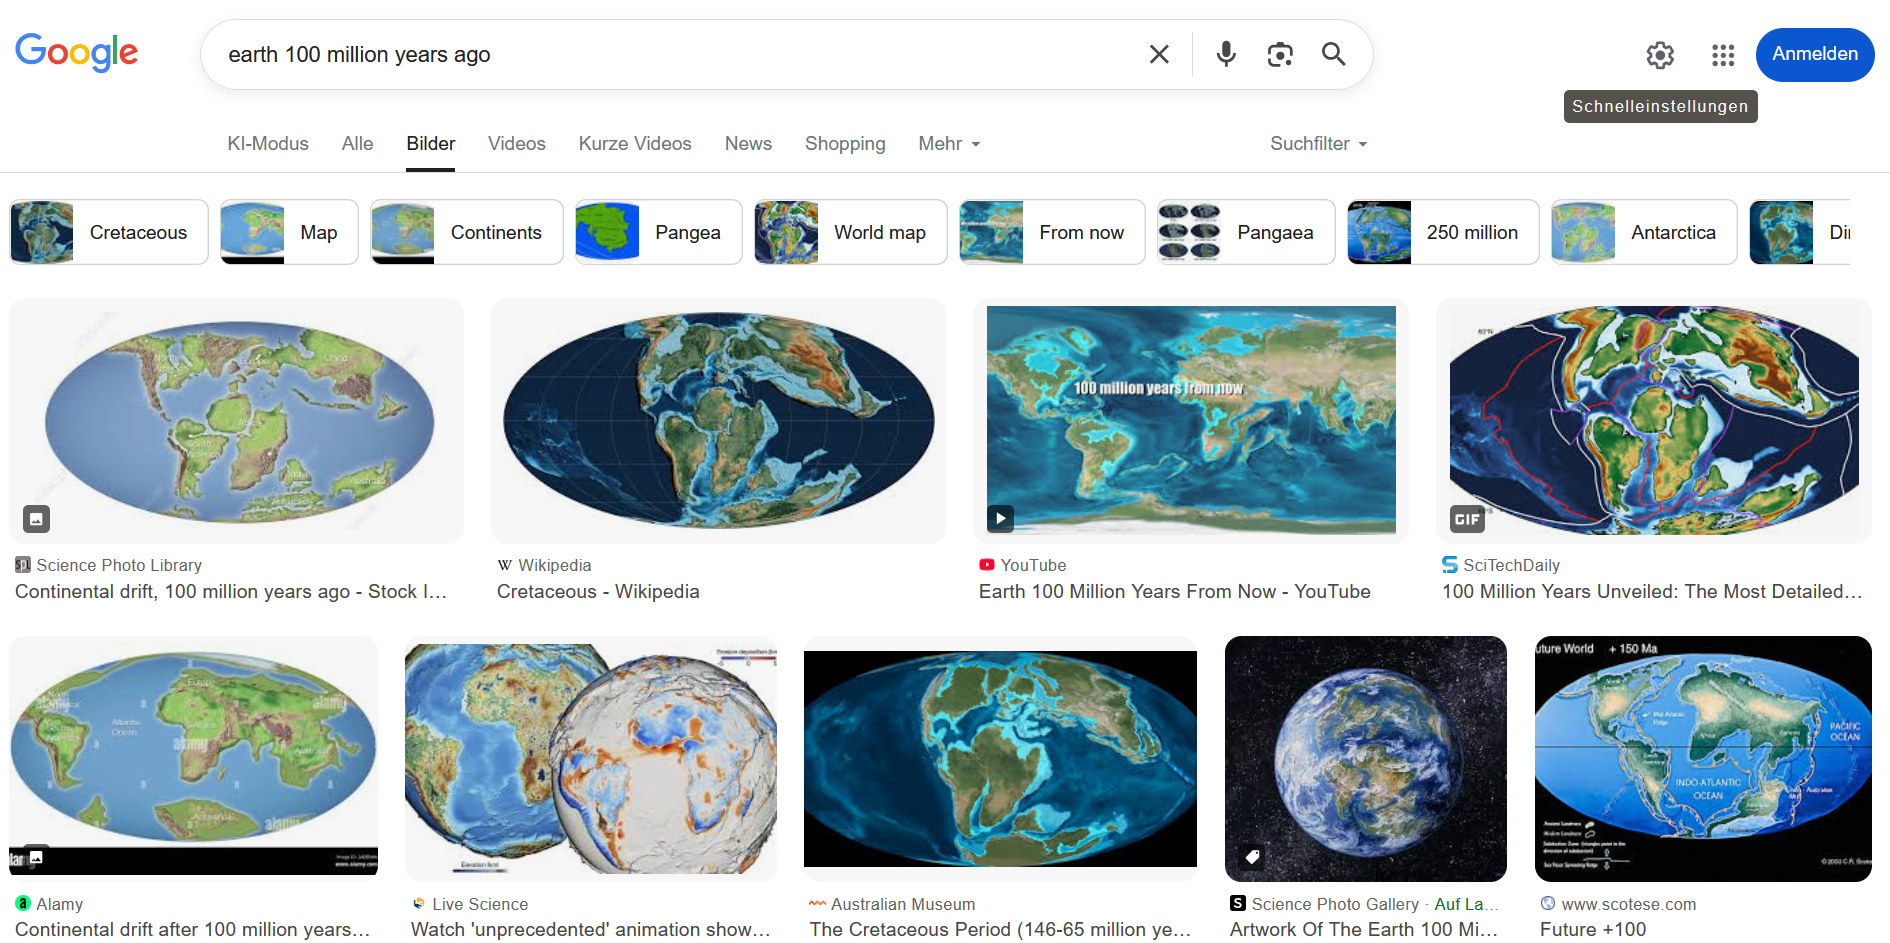
<figcaption aria-hidden="true">Example of Google Searcn results with the
Earth’s geography 100 millions of years ago</figcaption>
</figure>

> **Task**
>
> → Have a look at the various results, how many are actual maps
> (e.g. with formats that are compatible with geographic information
> systems (GIS) software ?

Do some maps look similar ? Do they share a common course ? Or, on the
contrary, do they look drastically different ?

In our exercise, we are particularly interested in having maps of the
entire Earth, and we we will see further, not only one (unique) map but
a series of maps showing us the evolution of the Earth for hundreds of
millions of years.

Among the most well known sources of data, you have a dataset created by
C. Scotese & N. Wright as part of the PALEOMAP project, accessible here
<https://doi.org/10.5281/zenodo.5460860>

This dataset contains 88 maps showing the palaeo Digital Elevation Model
(palaeo-DEM) over the Phanerozoic (from 541 Ma to present-day).

For 100Ma, the map would look like (with map resolution at 1x1°):

<figure>
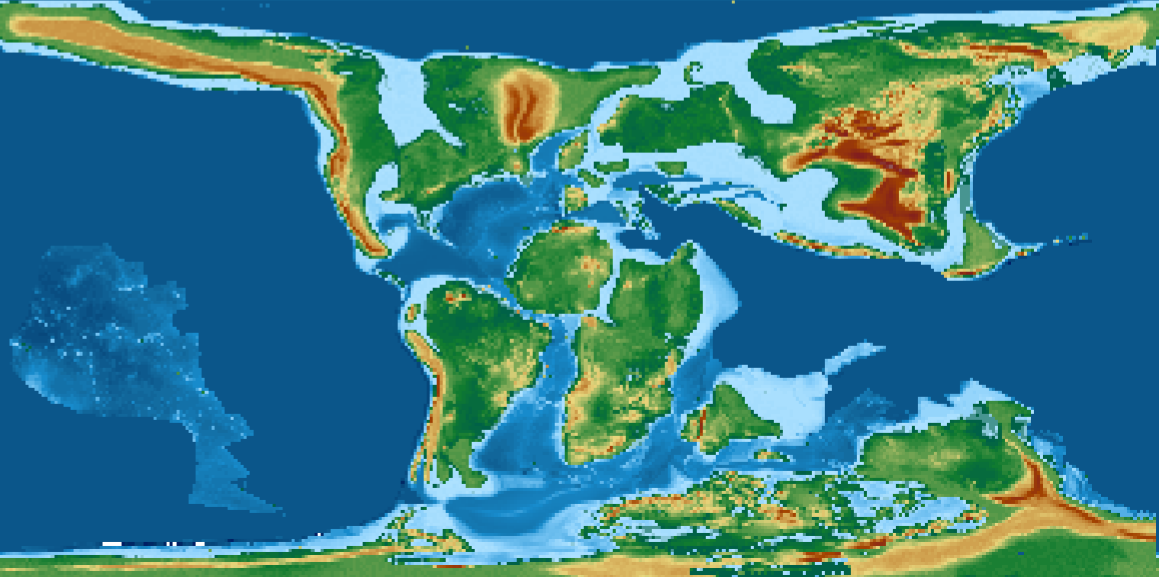
<figcaption aria-hidden="true">100Ma map from Scotese &amp; Wright
(2018) at 1x1° resolution</figcaption>
</figure>

> **Task**
>
> → Try and display the same map in your Desktop GIS. <br> → Explore the
> map. → Particularly, pay attention to the rendering of the topography.
> What do you observe on continents ? What about oceans ?
>
> It is easier to get the maps at 1x1° resolution from the EarthByte
> webpage listed in the Zenodo webpage record.

We found our first example very useful to get a sense of how the Earth
looked like 100 millions of years ago. However, we noticed some
limitations. We also want to benefit from the experience we have at the
University of Geneva in this domain.

We are going to use the PANALESIS plate tectonic model and its derived
palaeogeographic maps, that were developed at UNIGE.

The data is also available on Zenodo at
<https://doi.org/10.5281/zenodo.15396265>

> **Task**
>
> → Load the 100Ma map and compare it to the Scotese & Wright map. The
> PANALESIS map should look something like:

<figure>
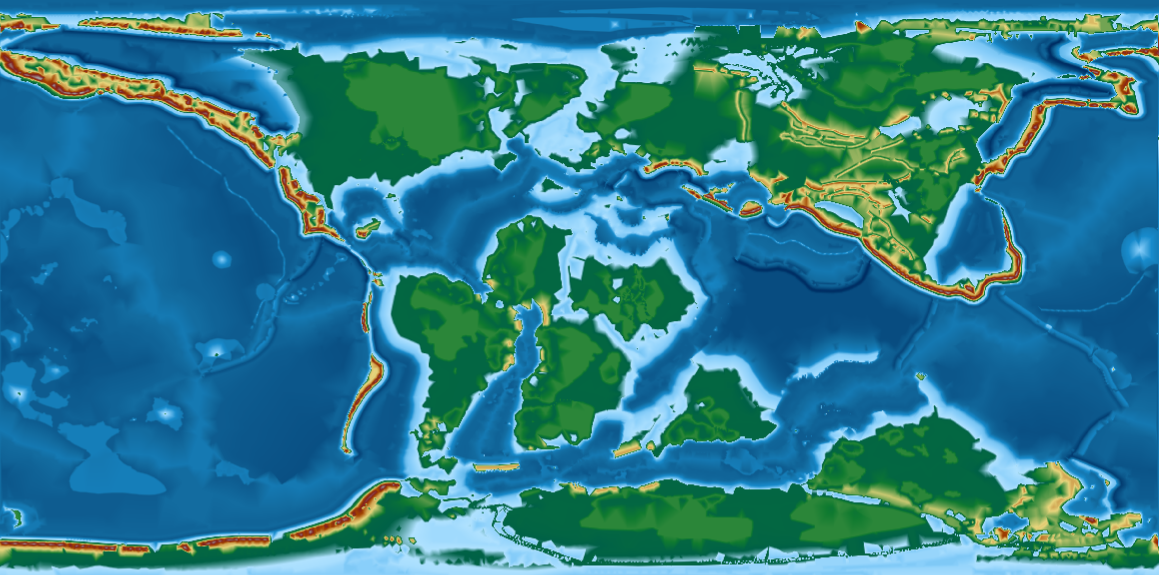
<figcaption aria-hidden="true">100Ma map from PANALESIS (Franziskakis et
al. (2026)) at 0.1x0.1° resolution</figcaption>
</figure>

### Load and inspect

In the two examples above, we manually downloaded maps from an open data
archive, and opened a single one with a dekstop GIS software. This may
be useful to have a first look at some data, yet, if we want to get a
deeper understanding of what our data can reveal, we need a simpler
(more direct) way to access and most importantly, to analyze our data.

Fortunately for us, there are some easy ways to serve geospatial data
directly to users via the web, to avoid downloading data on your local
machine each time you need it. To do this, we will have a look at the
Open Geospatial Consortium (OGC) web services, that include the Web Map
Servives (WMS), or the Web Coverage Services (WCS). These two types of
services are used on raster data. For vector data, the dedicated service
is the Web Feature Services (WFS).

We will use the OGC web services to get data that is stored in a server
dedicated to serve geospatial data (GeoServer). The common way to get
data is through a request using an URL that contains all elements
required by the web services. In our case, we will need to specify some
information on the following elements:

| Parameter | Description | Example value | Required |
|-----------------|-------------------|----------------------|---------------|
| `base_url` | Root URL of the GeoServer instance hosting the data | `https://geoserver.panalesis.org/geoserver/` | Yes |
| `workspace` | Name of the data store (workspace) inside the server | `panalesis_atlas_epsg_4326` | Yes |
| `service_type` | OGC service to use — WMS or WCS for raster data, WFS for vector data | `WCS` | Yes |
| `service_version` | Version of the OGC service protocol | `1.0.0` | Yes |
| `request_type` | Type of request sent to the service (e.g. GetCoverage, GetMap, GetFeature) | `GetCoverage` | Yes |
| `layer_name` | Name of the specific layer to access within the workspace | `palaeogeography_4326` | Yes |
| `crs` | Coordinate Reference System — defines the spatial projection | `EPSG:4326` | Yes |
| `bbox` | Bounding box as minLon, minLat, maxLon, maxLat — defines the spatial extent | `-180,-90,180,90` | Yes |
| `resx` / `resy` | Spatial resolution in CRS units (degrees for EPSG:4326) | `0.1` | Yes |
| `time` | ISO 8601 timestamp to select a specific time step from a temporal dataset | `2100-01-01T00:00:00.000Z` | Optional |
| `format` | Desired output format for the downloaded data | `GEOTIFF` | Yes |

We are going to retrieve the data from the PANALESIS server, which is
hosted by the University of Geneva, and available at
<https://geoserver.panalesis.org/geoserver/web/?2>.

If you open this link in your browser, and click on “Layer Preview”, you
will see all available layers. We will try and explore (almost) all of
them in this course. For now, our goal is still to access the
palaeogeographic map at 100Ma.

Typically, in our example, a correct URL for a web coverage service
(WCS), which will return a full map will look like:

In [2]:
base_url = "https://geoserver.panalesis.org/geoserver/"
workspace = "panalesis_atlas_epsg_4326"
service_type = "WCS"
service_version = "1.0.0"
request_type = "GetCoverage"
layer_name = "palaeogeography_4326"
crs = "EPSG:4326"
bbox = "-180,-90,180,90"
resx = "0.1"
resy = "0.1"
time = "2100-01-01T00:00:00.000Z"
format = "GEOTIFF"

wcs_url = (
    rf"{base_url}{workspace}/{service_type.lower()}?"
    rf"service={service_type}&"
    rf"version={service_version}&"
    rf"request={request_type}&"
    rf"coverage={workspace}:{layer_name}&"
    rf"crs={crs}&"
    rf"bbox={bbox}&"
    rf"resx={resx}&"
    rf"resy={resy}&"
    rf"time={time}&"
    rf"format={format}"
)
print(wcs_url)

> **Task**
>
> → Test what happens when you copy and paste this link in your browser.

Now we would like to directly retrieve the data, we can simply associate
it to a temporary layer and visualize it.

In [3]:
import requests
import matplotlib.pyplot as plt
from rasterio.io import MemoryFile

data = requests.get(wcs_url).content
with MemoryFile(data) as memfile:
    with memfile.open() as dataset:
        plt.imshow(
            dataset.read(1),
            cmap='terrain'
        )
        plt.colorbar()
        plt.show()

You can now recognize the same kind of map as shown above, with two
major differences. What are they ?

We are going to resolve this by adding a correct color ramp and setting
the axes to reflect longitude and latitude instead of pixel index.

In [4]:
import matplotlib.colors as mcolors
import numpy as np

colormap_entries = [
    (9000, "#ffffff", "9000"),
    (7000, "#cecece", "7000"),
    (5000, "#a1a1a1", "5000"),
    (3000, "#821e1e", "3000"),
    (2000, "#a34400", "2000"),
    (1000, "#e8d67d", "1000"),
    (200, "#107b30", "200"),
    (0, "#006147", "0"),
    (-100, "#b0e2ff", "-100"),
    (-500, "#87cefa", "-500"),
    (-2000, "#188ccd", "-2000"),
    (-4000, "#136ca0", "-4000"),
    (-7000, "#003266", "-7000"),
    (-9000, "#001e64", "-9000"),
    (-11000, "#000050", "-11000"),
]

colormap_entries_sorted = sorted(
    colormap_entries,
    key=lambda x: x[0]
)
elevations = [e[0] for e in colormap_entries_sorted]
colors = [e[1] for e in colormap_entries_sorted]

vmin, vmax = elevations[0], elevations[-1]
norm_values = [(e - vmin) / (vmax - vmin) for e in elevations]
cmap = mcolors.LinearSegmentedColormap.from_list(
    "palaeogeography",
    list(zip(norm_values, colors))
)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

data = requests.get(wcs_url).content
with MemoryFile(data) as memfile:
    with memfile.open() as dataset:
        raster = dataset.read(1).astype(float)

        nodata = dataset.nodata
        if nodata is not None:
            raster[raster == nodata] = np.nan

        bounds = dataset.bounds
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

        fig, ax = plt.subplots()
        img = ax.imshow(
            raster,
            cmap=cmap,
            norm=norm,
            extent=extent,
            origin="upper"
        )
        cbar = plt.colorbar(img, ax=ax)
        cbar.set_label("Elevation (m)")
        ax.set_xlabel("Longitude (°)")
        ax.set_ylabel("Latitude (°)")
        plt.show()

We now have the same result as the one above, and all elements making it
a comprehensive map are present (realistic colors, legend, axes labels).
However, we can go further and read some basic metadata from the WCS
request itself.

In [5]:
data = requests.get(wcs_url).content
with MemoryFile(data) as memfile:
    with memfile.open() as dataset:
        print(dataset.meta)
        print(dataset.bounds)
        print(dataset.crs)
        print(dataset.transform)

These few lines will give you useful information to understand the
nature of the data you are dealing with. the result will inform you
about the full list of attributes, including the data format, type, how
no-data value pixels are represented, the raster dimensions, the
coordinate reference system, and the “transform” which is the affine
transformation matrix to match the pixel position (x and y) in the
original file with their corresponding longitude and latitude.

> **Task**
>
> → Before going to the next part, write a quick summary about the data
> we just discuss:
>
> - Where does it come from ?
> - What does it represent ?
> - From a GIS perspective, what are the key properties of the dataset ?
> - Finally, from a geological point of view, what do you observe in the
>   map, compared to our present-day Earth ?

### Compute basic statistics

As you might have observed, we can immediately spot differences between
the world at 100Ma compared to the world we know today. We however need
a way to quantify these differences objectively. Fortunately for us,
this ca be performed quite easily with a few functions that we will
explore now.

Before diving into the analysis of our map, we however need to recognize
a limit with its dimensions. As noted before, the current CRS are the
“traditional” EPSG:4326 (WGS 1984), with units expressed in decimal
degrees. This is not useful if we want to compute areas. For this
reason, we will switch to the same map that are represented using an
equal area projection. In our case, we will use an equal area
projection.

The new WCS url is defined as follows:

In [6]:
base_url = "https://geoserver.panalesis.org/geoserver/"
workspace = "panalesis_atlas"
service_type = "WCS"
service_version = "1.0.0"
request_type = "GetCoverage"
layer_name = "palaeogeography"
crs = "EPSG:54034"
bbox = "-20037508.34,-6363885.33,20037508.34,6363885.33"
resx = "10000"
resy = "10000"
time = "2100-01-01T00:00:00.000Z"
format = "GEOTIFF"

wcs_url = (
    rf"{base_url}{workspace}/{service_type.lower()}?"
    rf"service={service_type}&"
    rf"version={service_version}&"
    rf"request={request_type}&"
    rf"coverage={workspace}:{layer_name}&"
    rf"crs={crs}&"
    rf"bbox={bbox}&"
    rf"resx={resx}&"
    rf"resy={resy}&"
    rf"time={time}&"
    rf"format={format}"
)
data = requests.get(wcs_url).content
with MemoryFile(data) as memfile:
    with memfile.open() as dataset:
        raster = dataset.read(1).astype(float)

        nodata = dataset.nodata
        if nodata is not None:
            raster[raster == nodata] = np.nan

        bounds = dataset.bounds
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

        fig, ax = plt.subplots()
        img = ax.imshow(
            raster,
            cmap=cmap,
            norm=norm,
            extent=extent,
            origin="upper"
        )
        cbar = plt.colorbar(img, ax=ax)
        cbar.set_label("Elevation (m)")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.show()

Notice how the bounds value changed: everything is not expressed in
meters, which are much better units than decimal degrees when
calculating areas.In our example, we will have a quick look at the land
and oceanic area, which are simply defined as the count of pixels
respectively above, and below or equal to 0m of elevation, multiplied by
the area of pixels.

This can be implemented using a very simple function:

In [7]:
def get_land_ocean_area(data, transform, extent, plot=False):
    pixel_area = abs(transform[0] * transform[4])

    # Masks
    land_mask = data >= 0
    ocean_mask = data < 0

    if plot:
        fig, ax = plt.subplots()
        img = ax.imshow(
            land_mask,
            cmap="Greys",
            interpolation="none",
            extent=extent,
            origin="upper"
        )

        # no colorbar for a mask
        ax.set_xlabel("Longitude (m)")
        ax.set_ylabel("Latitude (m)")
        plt.tight_layout()
        plt.show()

    land_area = np.sum(land_mask) * pixel_area
    ocean_area = np.sum(ocean_mask) * pixel_area

    return land_area, ocean_area


This function will take the input raster data and simply look for pixels
above sea-level to define them as land, and do the same with pixels at
or below sea-level and define in the ocean mask. Then, it will calculate
the respective areas by multiplying them by the pixel area.

You can call this function on the raster we previously loaded:

In [8]:
land_area, ocean_area = get_land_ocean_area(
    raster,
    dataset.transform,
    extent,
    plot=True
)
print("Land area =", land_area, "m²")
print("Ocean area =", ocean_area, "m²")

> **Task**
>
> → What do these number mean ? Are they realistic ?

We want to compare this value to the present-day world. Now, we know how
to do it, we simply need to change the data source and set it to the
present-day reconstruction. You might have observed how the time
dimension was defined in the previous requests. For instance, the 100Ma
map was obtained using `time = "2100-01-01T00:00:00.000Z"`. This is a
trick to follow the ISO 8601 standard. We simply add the geological age
(in millions of years) to the year 2000. For the 100Ma map, the code is
therefore 2**100**-01-01T00:00:00.000Z.

To obtain the map at present-day, we can create a new WCS request with
an updated `time` value and calculate the same statistics as we did for
100Ma:

In [9]:
time = "2000-01-01T00:00:00.000Z"

wcs_url = (
    rf"{base_url}{workspace}/{service_type.lower()}?"
    rf"service={service_type}&"
    rf"version={service_version}&"
    rf"request={request_type}&"
    rf"coverage={workspace}:{layer_name}&"
    rf"crs={crs}&"
    rf"bbox={bbox}&"
    rf"resx={resx}&"
    rf"resy={resy}&"
    rf"time={time}&"
    rf"format={format}"
)

data = requests.get(wcs_url).content
with MemoryFile(data) as memfile:
    with memfile.open() as dataset:
        raster = dataset.read(1).astype(float)

land_area, ocean_area = get_land_ocean_area(
    raster,
    dataset.transform,
    extent,
    plot=True
)
print("Land area =", land_area, "m²")
print("Ocean area =", ocean_area, "m²")

> **Task**
>
> → Are these number realistic ? Search for the actual land and ocean
> areas and compare them with your results.

### Deep-time trends

Finally, we are going to extend this analysis to all our available maps.
For this, we will simply create a loop that iterates through all time
steps and extract the values for land and ocean areas. First, we can
define a function that lists all available reconstructions. We can do
this using the The `xml.etree.ElementTree` module, a Python standard
library tool for parsing and navigating XML documents as a tree
structure, where each element (tag, attributes, text) is accessible as a
node.

In [10]:
from xml.etree import ElementTree as ET

def get_available_times(base_url, workspace,
                        service_type, service_version,
                        layer_name):
    describe_url = (
        f"{base_url}{workspace}/{service_type.lower()}?"
        f"service={service_type}&"
        f"version={service_version}&"
        f"request=DescribeCoverage&"
        f"coverage={workspace}:{layer_name}"
    )

    response = requests.get(describe_url)
    root = ET.fromstring(response.content)

    times = sorted(set(
        el.text for el in root.iter()
        if el.tag.endswith('timePosition') and el.text
    ))
    return sorted(times)

The response from the request we send to the server comes back as XML, a
nested syntax with tags that is very useful for machines to read text,
but not so much for us. In our case, we sent a `DescribeCoverage` for a
given layer, which yields back information about spatial and temporal
coverage of the layer. We are only interested in the `time` property so
this is why we filter out only values inserted inside the `timePosition`
tag.

If we call the function:

In [11]:
times = get_available_times(
    base_url,
    workspace,
    service_type,
    service_version,
    layer_name
)
print(times)

You can see that we have the times displayed here in the same format as
we have used before (tweaked time values, not the geological age in
millions of years). Now that we have a list with all available ages, it
is possible to iterate through this list and analyze the map associated
with every time step.

In the code snippet below, we create a `for` loop that will use each
value in the times list, extract the geological age value, create a WCS
request and get the data, calculate its land and ocean area, and store
them in a dictionary.

In [12]:
results = {}
for time in times:
    geological_age = int(time[:4]) - 2000
    wcs_url = (
        rf"{base_url}{workspace}/{service_type.lower()}?"
        rf"service={service_type}&"
        rf"version={service_version}&"
        rf"request={request_type}&"
        rf"coverage={workspace}:{layer_name}&"
        rf"crs={crs}&"
        rf"bbox={bbox}&"
        rf"resx={resx}&"
        rf"resy={resy}&"
        rf"time={time}&"
        rf"format={format}"
    )

    data = requests.get(wcs_url).content
    with MemoryFile(data) as memfile:
        with memfile.open() as dataset:
            raster = dataset.read(1).astype(float)

            nodata = dataset.nodata
            if nodata is not None:
                raster[raster == nodata] = np.nan

            bounds = dataset.bounds
            extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    land_area, ocean_area = get_land_ocean_area(
        raster,
        dataset.transform,
        False
    )
    results[geological_age] = {
        'land_area': float(land_area),
        'ocean_area': float(ocean_area)
    }
    del raster, data

print(results)

Finally, we can plot the evolution of these two variables through time.
In the example below, we create two separate plots, one for land,
another for oceans with a reversed x-axis value (0Ma = present-day is on
the right-side).

In [13]:
ages = list(results.keys())
land_areas = [results[age]['land_area'] for age in ages]
ocean_areas = [results[age]['ocean_area'] for age in ages]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

ax1.plot(ages, land_areas, color='darkgreen', marker='o', markersize=4)
ax1.set_xlabel('Age (Ma)')
ax1.set_ylabel('Land area (m²)')
ax1.invert_xaxis()
ax1.set_box_aspect(1)

ax2.plot(ages, ocean_areas, color='darkblue', marker='o', markersize=4)
ax2.set_xlabel('Age (Ma)')
ax2.set_ylabel('Ocean area (m²)')
ax2.invert_xaxis()
ax2.set_box_aspect(1)

plt.tight_layout()
plt.show()

> **Task**
>
> → What do you observe ?
>
> → You have seen what we can do with simple masks representing land and
> ocean. Do you have any ideas about other statistics we could easily
> plot ? Try it !

## Final questions

- When we loaded the data and metadata from the GeoServer, we found a
  `transform` attribute. What does this attribute describe ?
- What are the pros and cons of using WCS requests, compared with
  traditional ways, to access data ?
- We got familiar with the masking function to discriminate land and
  ocean. Could this mask be used to generate new statistics ? Which ones
  ?
- What is the use of these statistics in understanding the evolving
  palaeogeography throughout the Phanerozoic ?

## Links to useful libraries and tools

### Geospatial tools

- [`Web Map Service (WMS)`](https://www.ogc.org/standards/wms/) — An OGC
  standard protocol for requesting georeferenced map images (e.g., PNG,
  JPEG) from remote servers.

- [`Web Coverage Service (WCS)`](https://www.ogc.org/standards/wcs/) —
  An OGC standard for accessing raw raster datasets (“coverages”) such
  as elevation models, climate grids, and satellite imagery, preserving
  full numeric values.

### Python libraries

- [`matplotlib`](https://matplotlib.org/) A comprehensive plotting
  library for creating static, animated, and interactive visualizations
  in Python.

- [`numpy`](https://numpy.org/) The fundamental package for efficient
  numerical computing in Python, providing fast arrays and mathematical
  operations.

- [`rasterio`](https://rasterio.readthedocs.io/) A Python library for
  reading, writing, and manipulating geospatial raster data using GDAL
  under the hood.

- [`requests`](https://requests.readthedocs.io/) A simple and elegant
  HTTP library for sending web requests and interacting with APIs.

- [`xml.etree.ElementTree`](https://docs.python.org/3/library/xml.etree.elementtree.html)
  A Python standard library module for parsing and navigating XML
  documents as a tree structure, where each element’s tag, attributes,
  and text are accessible as nodes.